In [1]:
'''
Title : Heirarchical Clustering 
Author : raghav | GitHub : @raghavtwenty
Date Created : May 27, 2023 | Last Updated : May 27, 2023
Language : Python | Version : 3.11.3
'''

# Importing the required libraries 
import math


# Own Class
class heirarClus:
    """Hierarchical clustering class"""

    # -----
    def __init__(self):
        self.Points = points
        self.Len_Points = len(points)
        self.New_Matrix = []
        self.Inf = math.inf
        self.Dup = [[_] for _ in points]


    # -----
    def manDis(self, a,b):
        """Manhattan distance calculation"""

        return abs(a - b)

    # -----
    def minInMatrix(self, Min_Row, Min_Col):
        """Find the minimum in the matrix"""

        for row in range(self.Len_Points):
            for column in range(self.Len_Points):
                # Skip the diagonal 
                if (row != column):
                    Curr_Val = self.lis[row][column]
                    # Find the new min the matrix
                    if (Curr_Val < self.Inf):

                        self.Inf = Curr_Val
                        Min_Row = row
                        Min_Col = column
        
        self.Inf = math.inf
        return Min_Row, Min_Col



    # -----
    def proxiMatrix(self, points):
        """Create lists dynamically - square matrix"""

        self.lis = [[ self.manDis(_,__) for _ in points] for __ in points]

    # -----
    def calMatrix(self):
        """Proximity matrix updation, Calculation of proximity matrix"""

        # Loop till the end of the points len
        for times in range(self.Len_Points-1):

            Min_Row = 0
            Min_Col = 0

            # Find the new min in the matrix
            Min_Row, Min_Col = self.minInMatrix(Min_Row, Min_Col)
            print(f"Index of MIN element - ROW : {Min_Row}, COLUMN : {Min_Col}")

            # Change the dup list for final answer
            self.Dup[Min_Row].append(self.Dup[Min_Col])
            self.Dup.pop(Min_Col)

            

            # Drop the row 
            self.lis.pop(Min_Col)
            # Drop the Min Col in each row
            for item in range(len(self.lis)):
                self.lis[item].pop(Min_Col)
            

            self.printMatrix(self.lis, self.Dup)
            self.Len_Points -= 1

            print("_"*15+"END OF ITERATION : "+str(times)+"_"*15)
    

    # -----
    def printMatrix(self, matrix, points):
        """Prints the matrix row wise"""
        
        # Proximity matrix
        print(f"     {points}")
        for _ in range(len(matrix)):
            print(f"{points[_]} - {matrix[_]}")
        

    # -----
    def printAll(self): 
        """Prints all the variables inside this class"""

        print(f"Total Number of Points : {self.Len_Points}")
        self.printMatrix(self.lis, self.Points)





# Initial points
points = [18,22,25,27,42,43]

# Call the class
HC = heirarClus()
HC.proxiMatrix(points)
HC.printAll()

HC.calMatrix()

print(HC.Dup)




Total Number of Points : 6
     [18, 22, 25, 27, 42, 43]
18 - [0, 4, 7, 9, 24, 25]
22 - [4, 0, 3, 5, 20, 21]
25 - [7, 3, 0, 2, 17, 18]
27 - [9, 5, 2, 0, 15, 16]
42 - [24, 20, 17, 15, 0, 1]
43 - [25, 21, 18, 16, 1, 0]
Index of MIN element - ROW : 4, COLUMN : 5
     [[18], [22], [25], [27], [42, [43]]]
[18] - [0, 4, 7, 9, 24]
[22] - [4, 0, 3, 5, 20]
[25] - [7, 3, 0, 2, 17]
[27] - [9, 5, 2, 0, 15]
[42, [43]] - [24, 20, 17, 15, 0]
_______________END OF ITERATION : 0_______________
Index of MIN element - ROW : 2, COLUMN : 3
     [[18], [22], [25, [27]], [42, [43]]]
[18] - [0, 4, 7, 24]
[22] - [4, 0, 3, 20]
[25, [27]] - [7, 3, 0, 17]
[42, [43]] - [24, 20, 17, 0]
_______________END OF ITERATION : 1_______________
Index of MIN element - ROW : 1, COLUMN : 2
     [[18], [22, [25, [27]]], [42, [43]]]
[18] - [0, 4, 24]
[22, [25, [27]]] - [4, 0, 20]
[42, [43]] - [24, 20, 0]
_______________END OF ITERATION : 2_______________
Index of MIN element - ROW : 0, COLUMN : 1
     [[18, [22, [25, [27]]]], [4

Dendrogram

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as mpl
import pandas as pd

In [20]:
main_op = HC.Dup
print(main_op)

[[18, [22, [25, [27]]], [42, [43]]]]


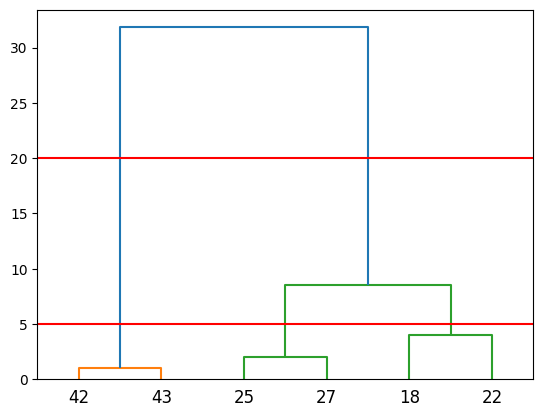

In [33]:
points = [18,22,25,27,42,43]
lab = ["18","22","25","27","42","43"]
points = pd.DataFrame(points)
link = linkage(points, 'ward')

dendrogram(link, labels=lab)
mpl.axhline(y=20, color = 'r')
mpl.axhline(y=5, color = 'r')
mpl.show()